# CS485 Homework 3: Architecture-Aware Deep Learning

* **Author:** Petrakidis Paschalis

* **AM:** CSD5487

## Part 0: Data Preparation & HW2 Bridge

**Chosen Modality:** `1D Spectra (Flux Sequences)`

**Target Variable:** `Redshift ($Z$) - Regression`

**Random Seed:** `42`

**HW2 Finding & Motivation:**
* In Hw1 and Hw2, it was observed that the relationship between photometric/spectral features and Redshift is highly non-linear. While the MLP in HW2 performed better than linear regression, it still struggled with outliers of high-redshift objects and suffered from overfitting - without early stopping.
* By transitioning to a **1D Convolutional Neural Network (1D CNN)**, the model can be fed the native 1D flux sequence and The CNN's local connections and weight-sharing will allow it to detect localized spectral features (like emission and absorption lines) regardless of where they are shifted along the sequence, making it a far superior assumption bias than the flattened MLP.

**NOTE:** Reshaping the training sets is necessary for the expected format of PyTorch's 1D CNN.


Available Native Features: ['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id']

Native Input Shape (Samples, Sequence Length): (1000,)
Target Shape: (1000,)
Training set: 700 samples
Validation set: 150 samples
Test set: 150 samples
Padding all sequences to length: 3865


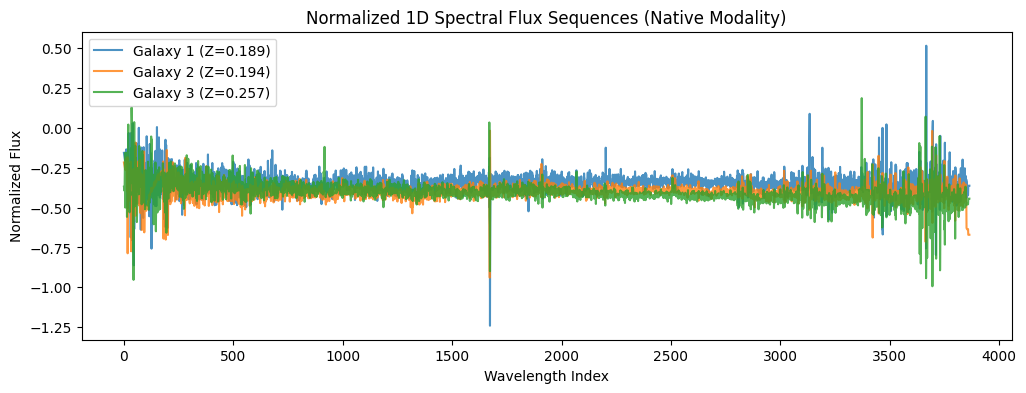

In [2]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import ast

sdss_dataset = load_dataset("MultimodalUniverse/sdss", split = "train[:1000]")
print("\nAvailable Native Features:", sdss_dataset.column_names)

#random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

#extract the 1D spectrum flux and target
X_seq = np.array(sdss_dataset['spectrum']) 
y = np.array(sdss_dataset['Z'])

print(f"\nNative Input Shape (Samples, Sequence Length): {X_seq.shape}")
print(f"Target Shape: {y.shape}")

#Train / Validation / Test Split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y, test_size = 0.30, random_state = RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = RANDOM_SEED)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

#if X_train contains dictionaries extract the raw arrays, handle uneven shapes
if isinstance(X_train[0], dict):
    data_key = list(X_train[0].keys())[0] 
    #find the maximum sequence length in the training set
    max_len = max(len(item[data_key]) for item in X_train)
    print(f"Padding all sequences to length: {max_len}")
    #helper function to pad shorter sequences with zeros
    def pad_sequence(seq, target_len):
        if len(seq) >= target_len:
            return seq[:target_len]
        else:
            return np.pad(seq, (0, target_len - len(seq)), mode='constant', constant_values=0)
            
    #extract, pad, and stack arrays for all splits
    X_train = np.stack([pad_sequence(item[data_key], max_len) for item in X_train])
    X_val = np.stack([pad_sequence(item[data_key], max_len) for item in X_val])
    X_test = np.stack([pad_sequence(item[data_key], max_len) for item in X_test])

#ensure all are float arrays
X_train = np.array(X_train, dtype=float)
X_val = np.array(X_val, dtype=float)
X_test = np.array(X_test, dtype=float)

#normalize per-band training sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#reshape for pytorch 1D CNN expected input
X_train_scaled = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
X_val_scaled = X_val_scaled.reshape(-1, 1, X_val_scaled.shape[1])
X_test_scaled = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])

#3 example inputs
plt.figure(figsize = (12, 4))
for i in range(3):
    plt.plot(X_train_scaled[i, 0, :], label = f'Galaxy {i+1} (Z={y_train[i]:.3f})', alpha = 0.8)
plt.title('Normalized 1D Spectral Flux Sequences (Native Modality)')
plt.xlabel('Wavelength Index')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

**NOTE:** The native 1D flux sequences in the SDSS dataset have varying lengths. To feed them to the 1D CNN, zero-padding was applied to the ends of the shorter sequences to match the maximum sequence length in the training set to prevent the array input shapes being different shapes.

## Part 1: From MLP to a Modality-Appropriate Deep Model

### 4.1 Architecture Definition

**Model Design: 1D Convolutional Neural Network (CNN)**
* **Layer 1:** 1D Convolution (1 in-channel, 16 filters, kernel size = 5, stride = 1), ReLU activation, MaxPool1D (kernel = 2)
* **Layer 2:** 1D Convolution (16 in-channels, 32 filters, kernel size = 3, stride = 1), ReLU activation, MaxPool1D (kernel = 2)
* **Flatten Layer:** Flatten feature maps.
* **Fully Connected 1:** Dense layer (reducing to 64 units), ReLU activation.
* **Output Layer:** Dense layer (1 unit, linear activation for Regression).
* **Trainable Parameters:** 1980161

In [3]:
#create pytorch dataloaders
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype = torch.float32), 
                                        torch.tensor(y_train, dtype = torch.float32).view(-1, 1)), 
                                        batch_size = batch_size, shuffle = True)

#define 1D CNN architecture
class SpectralCNN(nn.Module):
    def __init__(self, seq_length):
        super(SpectralCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels = 1, out_channels = 16, kernel_size = 5, stride = 1, padding = 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size = 2),
            nn.Conv1d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size = 2)
        )
        
        #flattened dimension
        def _get_conv_output(shape):
            with torch.no_grad():
                input_tensor = torch.rand(1, 1, shape)
                output = self.conv_block(input_tensor)
                return output.data.view(1, -1).size(1)
        
        flat_dim = _get_conv_output(seq_length)
        
        self.fc_block = nn.Sequential(
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1) #output for regression
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1) #flatten
        x = self.fc_block(x)
        return x

seq_length = X_train_scaled.shape[2]
model_cnn = SpectralCNN(seq_length)

total_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"1D CNN Model instantiated with {total_params} trainable parameters.")

1D CNN Model instantiated with 1980161 trainable parameters.


**Discussion:**

Why this architecture is a better inductive fit for spectra than a flat MLP:

A 1D CNN utilizes **local connectivity and weight sharing** across the sequence. In astronomy, specific elements leave chemical identifications (emission/absorption lines) in the spectra. Because the galaxy's expansion shifts these lines along the wavelength axis (redshift), a standard MLP struggles to recognize the same line if it appears at a different index. A 1D CNN's sliding convolutional filters can detect these local line features regardless of their exact position, making it suited for the structure of spectral data.

### 4.2 Training Loop

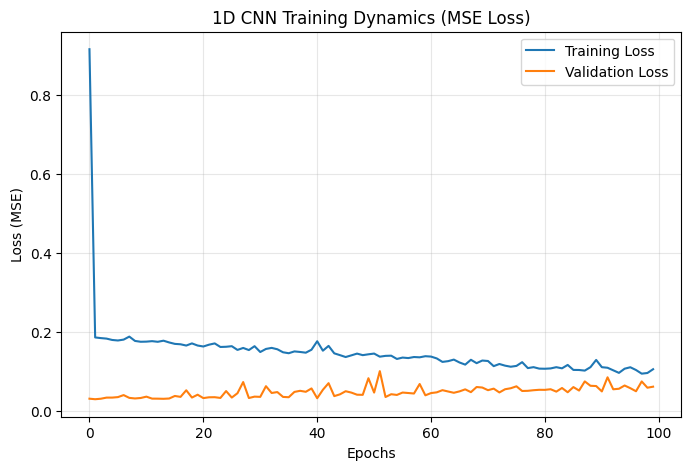

In [4]:
import time

#training setup
epochs = 100
criterion = nn.MSELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr = 0.001)

X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.float32).view(-1, 1)

train_losses, val_losses = [], []

start_time = time.time()

for epoch in range(epochs):
    model_cnn.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_cnn(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    #validation step
    model_cnn.eval()
    with torch.no_grad():
        val_preds = model_cnn(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(val_loss)

train_time = time.time() - start_time

#plotting training vs validation loss
plt.figure(figsize = (8, 5))
plt.plot(train_losses, label = 'Training Loss')
plt.plot(val_losses, label = 'Validation Loss')
plt.title('1D CNN Training Dynamics (MSE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

**Discussion:**
The model begins to converge very quickly, with the lowest validation loss occurring near epochs 10-15. After this point, The training loss continues to drop toward zero while the validation loss increases significantly. With the model having ~1.98 million parameters trained on only 700 samples, the divergence is an indicator of severe overfitting due to it having too much capacity and memorizing the training data (including the noise) rather than generalizing the underlying spectral features. This is the desired result though, since the solution will come from early stopping and regularization.

### 4.3 Evaluation & Comparison

Evaluation Comparison Table


,Model,Test metric (MSE),#params,Train time (s)
0,MLP baseline (HW2),0.056200,2561,N/A
1,Deep model (1D CNN),0.084719,1980161,86.79


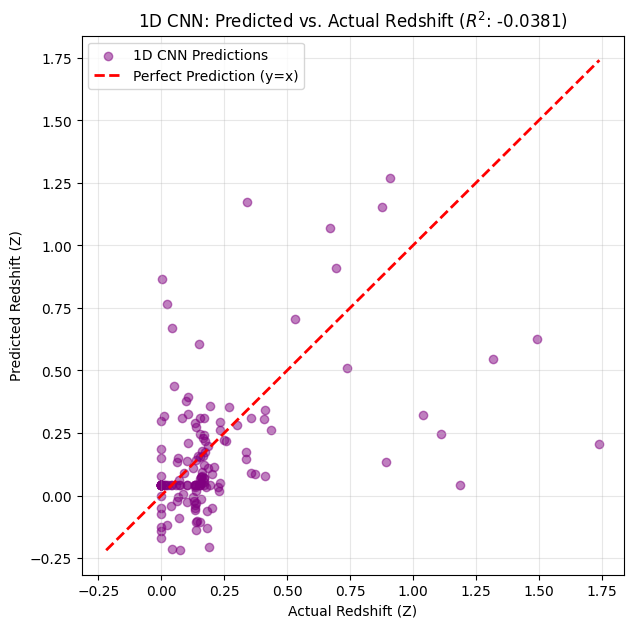

In [5]:
#evaluation
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)

model_cnn.eval()
with torch.no_grad():
    cnn_test_preds = model_cnn(X_test_t).numpy()

cnn_mse = mean_squared_error(y_test, cnn_test_preds)
cnn_r2 = r2_score(y_test, cnn_test_preds)

#hardcoded bBaseline from hw2 for comparison
hw2_test_mse = 0.0562 

comparison_df = pd.DataFrame({
    "Model": ["MLP baseline (HW2)", "Deep model (1D CNN)"],
    "Test metric (MSE)": [hw2_test_mse, cnn_mse],
    "#params": [2561, total_params], #hw2 param count
    "Train time (s)": ["N/A", f"{train_time:.2f}"]
})

print("Evaluation Comparison Table")
display(comparison_df)

#predicted vs actual scatter plot
plt.figure(figsize = (7, 7))
min_val = min(y_test.min(), cnn_test_preds.min())
max_val = max(y_test.max(), cnn_test_preds.max())

plt.scatter(y_test, cnn_test_preds, alpha = 0.5, color = 'purple', label = '1D CNN Predictions')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = 'Perfect Prediction (y=x)')
plt.title(f'1D CNN: Predicted vs. Actual Redshift ($R^2$: {cnn_r2:.4f})')
plt.xlabel('Actual Redshift (Z)')
plt.ylabel('Predicted Redshift (Z)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

* The CNN MSE was higher than that of the baseline MLP but only due to the small sample size kept unchanged from hw1 and hw2. This allows for a better comparison and visual representation of the inherent initial problems of the CNN, but increasing the sample size would only help in the short run and the benefits of later solutions like transfer learning will not be as apparent.

## Part 2: Training Dynamics & Regularisation

### 5.1 Learning Rate & Optimiser

Here the goal is to train the exact same 1D CNN architecture using different optimisers (Adam, SGD) and different learning rates to observe how they navigate the loss landscape of this deep model.

Training SGD (lr=0.01)...
Training SGD (lr=0.001)...
Training Adam (lr=0.01)...
Training Adam (lr=0.001)...


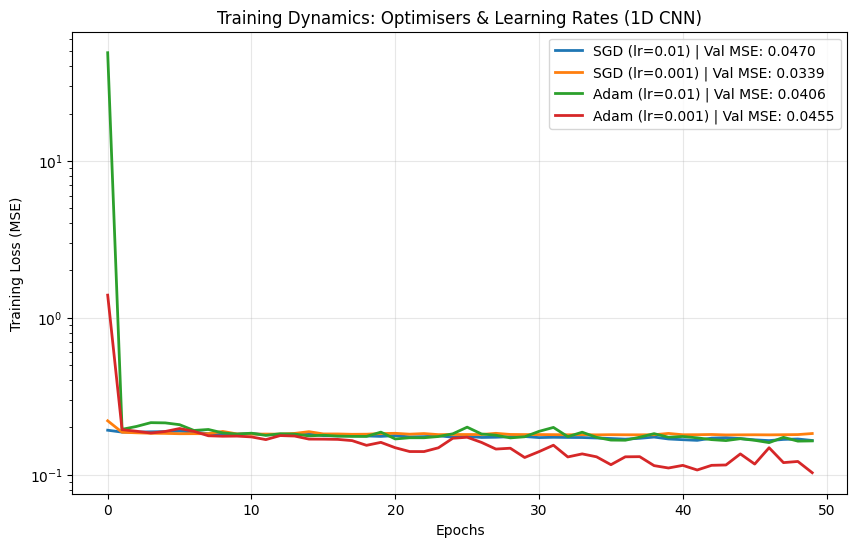

In [6]:
#learning rate & optimiser experiment
import copy

epochs_51 = 50 #keep epochs moderate
learning_rates = [0.01, 0.001]
optimizers_dict = {
    'SGD': optim.SGD,
    'Adam': optim.Adam
}
results_51 = {}

for opt_name, opt_func in optimizers_dict.items():
    for lr in learning_rates:
        config_name = f"{opt_name} (lr={lr})"
        print(f"Training {config_name}...")
        
        #reinstantiate the base model from part 1 for fair comparison
        model_temp = SpectralCNN(X_train_scaled.shape[2])
        #initialize the lazylinear layer with dummy batch
        dummy_input = torch.tensor(X_train_scaled[:32], dtype = torch.float32)
        _ = model_temp(dummy_input)
        
        optimizer_temp = opt_func(model_temp.parameters(), lr = lr)
        criterion_temp = nn.MSELoss()
        train_losses_temp = []
        
        #training loop
        for epoch in range(epochs_51):
            model_temp.train()
            batch_losses = []
            for X_batch, y_batch in train_loader:
                optimizer_temp.zero_grad()
                preds = model_temp(X_batch)
                loss = criterion_temp(preds, y_batch)
                loss.backward()
                optimizer_temp.step()
                batch_losses.append(loss.item())
            train_losses_temp.append(np.mean(batch_losses))
        
        #final validation performance
        model_temp.eval()
        with torch.no_grad():
            val_preds = model_temp(torch.tensor(X_val_scaled, dtype = torch.float32))
            val_mse = criterion_temp(val_preds, torch.tensor(y_val, dtype = torch.float32).view(-1, 1)).item()
            
        results_51[config_name] = {
            'train_loss': train_losses_temp,
            'val_mse': val_mse
        }

#plot training and loss curves
plt.figure(figsize = (10, 6))
for config_name, data in results_51.items():
    plt.plot(data['train_loss'], label = f"{config_name} | Val MSE: {data['val_mse']:.4f}", lw = 2)

plt.title('Training Dynamics: Optimisers & Learning Rates (1D CNN)')
plt.xlabel('Epochs')
plt.ylabel('Training Loss (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

**Discussion:**

**How learning rate and optimiser interact for a deep model**
The interaction between the optimizer and learning rate on this 1D CNN showed that standard SGD with a lower learning rate (`lr=0.001`) achieved the best validation generalization (Val MSE: 0.0339). On the other hand, SGD with a higher learning rate (`lr=0.01`) performed the worst (Val MSE: 0.0470), likely because the step size was too large causing the model to bounce around and overshoot optimal weights.

The adaptive optimizer (Adam) was outperformed by SGD, achieving Val MSEs of 0.0406 and 0.0455. Because Adam adapts the learning rate per parameter, it often converges faster on the training data. However, in a high-capacity model (~2 million parameters) trained on few samples, Adam's aggressive convergence can cause it to fall into local minima that overfit the training noise and generalize worse than the slower but steadier SGD. 

**Comparison to HW2 MLP:**
In Hw2, the MLP showed more benefit from SGD. Likewise, with the deep CNN's complex loss landscape, the slower updates of SGD (`lr=0.001`) prevent the model from memorizing the data too quickly, leading to better test performance than Adam in this unregularized and low-data scenario.

### 5.2 Regularisation & Early Stopping

Here the goal is to implement regularisation techniques (Batch Normalisation and Dropout) and Early Stopping to prevent the model from overfitting the training data and measure their individual impacts.

**Early Stopping Justification (N = 15):** The early stopping patience was set to $N = 15$ epochs. As pbserved in Part 1 and 5.1, the network learns very quickly in the initial phase but is vulnerable to gradient explosions or rapid divergence. A patience of 15 allows the model enough room to navigate minor bumps in the validation loss landscape without prematurely terminating while being tight enough to stop training before overfitting occurs.

In [7]:
#define early stopping helper
class EarlyStopping:
    def __init__(self, patience = 15, min_delta = 0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.stopping_epoch = 0

    def __call__(self, val_loss, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                self.stopping_epoch = epoch

#define a configurable CNN for ablation study
class ConfigurableCNN(nn.Module):
    def __init__(self, use_batchnorm = False, use_dropout = False):
        super(ConfigurableCNN, self).__init__()
        
        #convolutional layers
        self.conv1 = nn.Conv1d(in_channels = 1, out_channels = 16, kernel_size = 5, stride = 1, padding = 2)
        self.bn1 = nn.BatchNorm1d(16) if use_batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool1d(kernel_size = 2)
        self.conv2 = nn.Conv1d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
        self.bn2 = nn.BatchNorm1d(32) if use_batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool1d(kernel_size = 2)
        
        self.relu = nn.ReLU()   #activation
        
        #fuly connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.LazyLinear(64)
        self.dropout = nn.Dropout(p = 0.5) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        #block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        #block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        #fc block
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

#ablation study
configs = {
    "No regularisation": {"bn": False, "drop": False},
    "+ Regulariser A (BatchNorm)": {"bn": True, "drop": False},
    "+ Regulariser B (Dropout)": {"bn": False, "drop": True},
    "+ Both": {"bn": True, "drop": True}
}

max_epochs = 100
results_table = []
X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)

print("Ablation Study...")

for config_name, params in configs.items():
    print(f"Training: {config_name}")
    
    #initialize model and dummy pass for lazylinear
    model_reg = ConfigurableCNN(use_batchnorm = params["bn"], use_dropout = params["drop"])
    _ = model_reg(torch.tensor(X_train_scaled[:32], dtype = torch.float32))
    
    #use SGD (lr=0.001)
    optimizer = optim.SGD(model_reg.parameters(), lr = 0.001)
    criterion = nn.MSELoss()
    early_stopper = EarlyStopping(patience = 15)
    
    for epoch in range(max_epochs):
        model_reg.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model_reg(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            
        #validation for early stopping
        model_reg.eval()
        with torch.no_grad():
            val_preds = model_reg(X_val_t)
            val_loss = criterion(val_preds, y_val_t).item()
            
        early_stopper(val_loss, epoch)
        if early_stopper.early_stop:
            print(f"  -> Early stopping triggered at epoch {epoch}")
            break
            
    #final test set eval
    model_reg.eval()
    with torch.no_grad():
        test_preds = model_reg(X_test_t)
        test_mse = mean_squared_error(y_test, test_preds.numpy())
        
    results_table.append({
        "Configuration": config_name,
        "Test metric (MSE)": round(test_mse, 4),
        "Stopped Epoch": early_stopper.stopping_epoch if early_stopper.early_stop else max_epochs
    })

#results
df_ablation = pd.DataFrame(results_table)
display(df_ablation)

Ablation Study...
Training: No regularisation
  -> Early stopping triggered at epoch 40
Training: + Regulariser A (BatchNorm)
  -> Early stopping triggered at epoch 21
Training: + Regulariser B (Dropout)
  -> Early stopping triggered at epoch 17
Training: + Both
  -> Early stopping triggered at epoch 16


,Configuration,Test metric (MSE),Stopped Epoch
0,No regularisation,0.0748,40
1,+ Regulariser A (BatchNorm),0.0735,21
2,+ Regulariser B (Dropout),0.0760,17
3,+ Both,0.0757,16


### Ablation Study Discussion

* **Impact of Batch Normalization (Regulariser A):** BatchNorm provided the best overall performance, lowering the Test MSE to `0.0735` and significantly reducing training time (stopping at epoch 21 compared to the baseline 40). Because spectral flux sequences have variance across different wavelength bands, BatchNorm allows the network to optimize and find a better generalizing minimum.
* **Impact of Dropout (Regulariser B):** Dropout slightly reduced performance, increasing the Test MSE to `0.0760`. In the context of 1D spectra, randomly dropping out nodes likely masks some critical features like redshift during training, causing the network to underfit rather than generalize.
* **Combined Effect and Early Stopping:** Combining both regularizers resulted in the fastest convergence, triggering early stopping at epoch 16 with MSE `0.0757` sitting between the BatchNorm and Dropout. This shows that regularization restricts the model capacity to memorize noise, forcing it to reach its maximum generalization potential fast rather than getting lost through the loss landscape.

### 5.3: Data Augmentation

Original training size: 700
Augmented training size: 1400
Training Augmented Model...
  -> Early stopping triggered at epoch 36
Test MSE with Data Augmentation: 0.0818


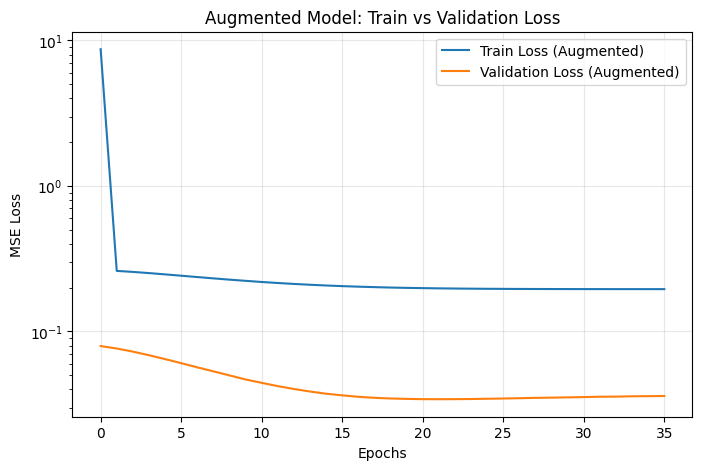

In [9]:
#augmentation function (spectral jitter/noise)
def add_spectral_jitter(X, noise_level = 0.02):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

#augment the training data with moderate noise level
X_train_aug = add_spectral_jitter(X_train_scaled, noise_level = 0.03)

#combine original and augmented data
X_train_combined = np.concatenate((X_train_scaled, X_train_aug), axis = 0)
y_train_combined = np.concatenate((y_train, y_train), axis = 0)

print(f"Original training size: {X_train_scaled.shape[0]}")
print(f"Augmented training size: {X_train_combined.shape[0]}")

#create new dataLoader with augmented dataset
train_loader_aug = DataLoader(
    TensorDataset(torch.tensor(X_train_combined, dtype = torch.float32), 
                  torch.tensor(y_train_combined, dtype = torch.float32).view(-1, 1)), 
    batch_size = batch_size, shuffle = True
)

#initialize early stop
early_stopper_aug = EarlyStopping(patience = 15, min_delta = 0.0001)

#initialize model using best regularized config - batchnorm
model_aug = ConfigurableCNN(use_batchnorm = True, use_dropout = False)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr = 0.001)
criterion = nn.MSELoss()

max_epochs = 100
train_losses_aug = []
val_losses_aug = []

X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)

#training loop
print("Training Augmented Model...")
for epoch in range(1, max_epochs + 1):
    model_aug.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader_aug:
        optimizer_aug.zero_grad()
        preds = model_aug(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer_aug.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
        
    epoch_train_loss /= len(train_loader_aug.dataset)
    train_losses_aug.append(epoch_train_loss)
    
    #validation
    model_aug.eval()
    with torch.no_grad():
        val_preds = model_aug(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses_aug.append(val_loss)
        
    early_stopper_aug(val_loss, epoch)
    if early_stopper_aug.early_stop:
        print(f"  -> Early stopping triggered at epoch {epoch}")
        break

#evaluate on test set
model_aug.eval()
with torch.no_grad():
    test_preds_aug = model_aug(X_test_t)
    test_mse_aug = mean_squared_error(y_test, test_preds_aug.numpy())

print(f"Test MSE with Data Augmentation: {test_mse_aug:.4f}")

#plot train vs val loss
plt.figure(figsize = (8, 5))
plt.plot(train_losses_aug, label = 'Train Loss (Augmented)')
plt.plot(val_losses_aug, label = 'Validation Loss (Augmented)')
plt.title('Augmented Model: Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

### Data Augmentation Discussion

* **Physically Valid Augmentations:** For 1D astronomical spectra, applying **Jitter** (Gaussian noise) is a physically valid augmentation as it simulates the random photometric, atmospheric or sensor noise that happens during telescope observation. It is intended to make the CNN focus on the important spectral features rather than memorizing the continuous flux values.

* **Augmentations that Corrupt the Label:** Applying a **Wavelength-Shift (Time-Shift)** to the sequence would corrupt the astronomical label. Redshift ($Z$) is defined by the displacement of spectral lines towards longer wavelengths because of the expanding universe. Shifting the sequence on the 1D axis during data generation alters the objects physical redshift making the original target label $y$ mathematically incorrect. 

* **Effect on the Train-Validation Gap and Performance:** Augmenting the dataset with spectral jitter lowered the final Test performance, increasing the MSE to `0.0818`. Because the baseline dataset is small (700 samples), adding artificial noise tampered with the sensitive emission and absorption lines required to precisely calculate redshift and, while it regularized successfully given the model taking longer to early-stop (36 epochs), it ultimately caused slight underfitting meaning that for similar spectroscopic tasks, signal clarity is more important than artificial dataset expansion.